In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="GD8tH6KEirCm0I5ySSBD")
project = rf.workspace("fire-test-w38ww").project("fire-dji3l")
version = project.version(4)
dataset = version.download("yolo26")


  Using cached numpy-2.3.5-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 MB 27.9 MB/s  0:00:017.7 MB/s eta 0:00:01:01
Using cached numpy-2.3.5-cp314-cp314-macosx_14_0_arm64.whl (5.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 959.7/959.7 kB 25.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 18.7 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [roboflow];237m━━ 15/16 [roboflow]thon-headless]
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to fire--4 in yolo26:: 100%|██████████| 30202/30202 [00:02<00:00, 12926.40it/s]


In [2]:
!pip install ultralytics

In [4]:
 !system_profiler SPDisplaysDataType

Graphics/Displays:

    Apple M4:

      Chipset Model: Apple M4
      Type: GPU
      Bus: Built-In
      Total Number of Cores: 10
      Vendor: Apple (0x106b)
      Metal Support: Metal 4
      Displays:
        ASUS PA279CV:
          Resolution: 5120 x 2880 (5K/UHD+ - Ultra High Definition Plus)
          UI Looks like: 2560 x 1440 @ 60.00Hz
          Main Display: Yes
          Mirror: Off
          Online: Yes
          Rotation: Supported
        ASUS PA279CV:
          Resolution: 5120 x 2880 (5K/UHD+ - Ultra High Definition Plus)
          UI Looks like: 2560 x 1440 @ 60.00Hz
          Mirror: Off
          Online: Yes
          Rotation: Supported



In [5]:
import numpy as np

import torch
from torchvision.io import read_image

from ultralytics import YOLO

import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [7]:
def display_images(image_list=None, title=None, bboxes_list=None):
    if image_list is None:
        image_list = []

    if title is None:
        title = ""

    if bboxes_list is None:
        bboxes_list = []

    #(False, True)
    if not any(isinstance(i, list) for i in image_list):
        image_list = [image_list] #[img, img, img] => [[img, img, img]]

    rows = len(image_list)
    cols = max(len(row) if isinstance(row , list) else 1 for row in image_list)

    plt.suptitle(title)
    fig, ax = plt.subplots(rows, cols)

    #确保ax是2D数组
    #ax => [[ax]], [ax]=>[[ax]]
    ax = np.atleast_2d(ax)

    for i, row in enumerate(image_list):
        if not isinstance(row, list):
            row = [row]

        for j, img in enumerate(row):
            ax[i, j].imshow(img)
            ax[i, j].axis("off")

            bbox_index = i * cols + j
            if bbox_index < len(bboxes_list):
                for bbox in bboxes_list[bbox_index]:
                    x_min, y_min, x_max, y_max = bbox
                    width = x_max - x_min
                    height = y_max - y_min
                    rect = patches.Rectangle(
                        (x_min, y_min),
                        width,
                        height,
                        linewidth=2,
                        edgecolor="r",
                        facecolor="none"
                    )
                    ax[i, j].add_patch(rect)

        for j in range(len(row), cols):
            ax[i, j].axis("off")

    #plt.tight_layout()
    plt.show()

<Figure size 640x480 with 0 Axes>

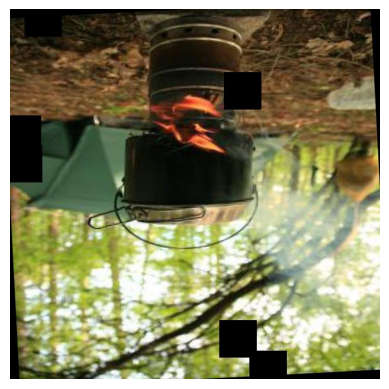

In [10]:
org_image_path = '/Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/fire--4/train/images/0050_jpg.rf.735bdf9c97cead8499836ed82c003320.jpg'
img = read_image(org_image_path)
display_images(img.permute(1,2,0))

In [11]:
MODEL_PATH = 'yolo26n.pt'
print("loading model....")
model = YOLO(MODEL_PATH)
print("model loaded")

loading model....
model loaded


In [13]:
results = model(org_image_path, device="mps")



image 1/1 /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/fire--4/train/images/0050_jpg.rf.735bdf9c97cead8499836ed82c003320.jpg: 640x640 (no detections), 10.7ms
Speed: 167.8ms preprocess, 10.7ms inference, 5.7ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 640x480 with 0 Axes>

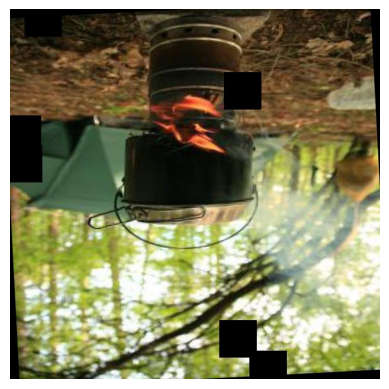

In [14]:
boxes = []
for result in results:
    xyxy = result.boxes.xyxy
    boxes.append(xyxy.cpu())

display_images(img.permute(1,2,0), bboxes_list=boxes)

In [16]:
model.train(data="/Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/fire--4/data.yaml", epochs=50, imgsz=640, device="mps")

New https://pypi.org/project/ultralytics/8.4.119 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.117 🚀 Python-3.14.3 torch-2.13.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/fire--4/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_rati

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


       1/50      5.39G      2.466      4.568    0.02782          7        640: 100% ━━━━━━━━━━━━ 854/854 1.1it/s 12:511.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 1.4it/s 22.9s0.6ss
                   all        966       1564      0.449      0.403      0.373      0.131

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       2/50      5.32G      1.853      2.402    0.02497         36        640: 0% ──────────── 0/854  1.1s

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


       2/50      5.39G      1.927      2.204    0.02035          8        640: 100% ━━━━━━━━━━━━ 854/854 1.1it/s 12:450.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 1.4it/s 22.0s0.6ss
                   all        966       1564      0.635      0.556      0.587      0.271

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       3/50      5.31G      1.792       1.82    0.01792         50        640: 0% ──────────── 0/854  1.1s

...

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


      49/50      5.38G      0.958     0.3908    0.00934          4        640: 100% ━━━━━━━━━━━━ 854/854 1.1it/s 12:410.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 1.4it/s 21.7s0.6ss
                   all        966       1564      0.924      0.865      0.925      0.603

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size


index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


      50/50      5.35G      0.954     0.3844   0.009335          5        640: 100% ━━━━━━━━━━━━ 854/854 1.1it/s 12:450.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 1.4it/s 21.6s0.6ss
                   all        966       1564      0.922      0.869      0.924      0.605

50 epochs completed in 10.743 hours.
Optimizer stripped from /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/runs/detect/train-2/weights/last.pt, 5.4MB
Optimizer stripped from /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/runs/detect/train-2/weights/best.pt, 5.4MB

Validating /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/runs/detect/train-2/weights/best.pt...
Ultralytics 8.4.117 🚀 Python-3.14.3 torch-2.13.0 MPS (Apple M4)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  m

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x332e50050>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,    

In [17]:

NEW_MODEL_PATH = '/Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/runs/detect/train-2/weights/best.pt'
print("loading new model....")
new_model = YOLO(NEW_MODEL_PATH)
print("model new loaded")

preds  = new_model(org_image_path, device="mps")

loading new model....
model new loaded

image 1/1 /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/fire--4/train/images/0050_jpg.rf.735bdf9c97cead8499836ed82c003320.jpg: 640x640 1 fire, 9.4ms
Speed: 1.9ms preprocess, 9.4ms inference, 4.2ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 640x480 with 0 Axes>

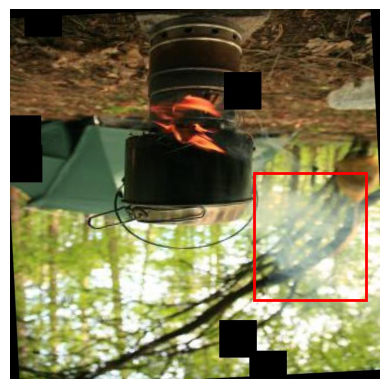

In [18]:
newboxes = []
for result in preds:
    xyxy = result.boxes.xyxy
    newboxes.append(xyxy.cpu())

display_images(img.permute(1,2,0), bboxes_list=newboxes)